# HW2: Data Processing
## MML1 Projekt: Predikce doby průchodu Mythic+ dungeonem (Pit of Saron) podle složení skupiny

## 1. Navázání na DÚ1: Task framing

**Business problém:** U top EU hráčů Mythic+ se skupiny liší v tom, jak rychle dokáží projít dungeonem. Otázka je, zda lze dobu průchodu předpovědět ze složení skupiny.

**Analytická úloha:** Regrese, predikce doby průchodu dungeonem z pre-run proměnných.

**Výzkumná otázka:** V rámci klíče +16, může složení skupiny (class a spec hráčů) předpovědět dobu průchodu Pit of Saron nad rámec toho, co vysvětluje průměrný item level skupiny?

**Jednotka pozorování:** Jeden dokončený Mythic+ run na úrovni +16 (5 hráčů, jeden dungeon).

**Cílová proměnná:** `clear_time_ms`, skutečná doba průchodu dungeonem v milisekundách (post-run).

**Hlavní metrika:** RMSE v sekundách.

**Omezení datasetu:** Všechny runy pocházejí z top-ranked části EU populace přes rankings endpoint raider.io. Výsledky nelze zobecňovat na běžné hráče.

## 2. Popis dat

Načítáme `raiderio_runs_saron_clean.csv`, což je výstup skriptu `src/pyWowClean.py`. Ten provedl deduplikaci a imputaci chybějících ilvl hodnot ze surových dat scrapovaných přes Raider.IO API.

Dataset filtrujeme na úroveň klíče **+16**. Je to nejzastoupenější úroveň (46 % runů) a filtrem odstraníme dominantní vliv obtížnosti na dobu průchodu. Výzkumná otázka se tak stává čistší: v rámci stejné obtížnosti, předpovídá složení skupiny jak rychle dungeon projdou? Časový vývoj (sezóna trvá několik týdnů) v datech zůstává zachován.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

df = pd.read_csv("raiderio_runs_saron_clean.csv")
df = df[df["mythic_level"] == 16].copy().reset_index(drop=True)

print(f"Počet řádků po filtru na +16: {len(df)}")
print(f"Počet sloupců: {len(df.columns)}")
df.dtypes

Počet řádků po filtru na +16: 8730
Počet sloupců: 55


keystone_run_id         int64
keystone_team_id        int64
completed_at              str
season                    str
mythic_level            int64
keystone_time_ms        int64
faction                   str
dungeon_name              str
dungeon_short_name        str
dungeon_slug              str
dungeon_patch         float64
modifier_1                str
modifier_2                str
modifier_3                str
tank_name                 str
tank_race                 str
tank_race_id            int64
tank_class                str
tank_class_id           int64
tank_spec                 str
tank_spec_id            int64
tank_ilvl             float64
healer_name               str
healer_race               str
healer_race_id          int64
healer_class              str
healer_class_id         int64
healer_spec               str
healer_spec_id          int64
healer_ilvl           float64
dps_1_name                str
dps_1_race                str
dps_1_race_id           int64
dps_1_clas

In [2]:
# Chybějící hodnoty
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [3]:
# Duplicity (po předchozím čištění by měly být nulové)
n_dup = df.duplicated(subset="keystone_run_id").sum()
print(f"Duplicitní keystone_run_id: {n_dup}")

Duplicitní keystone_run_id: 0


In [4]:
# Popis cílové proměnné
TARGET = "clear_time_ms"
print((df[TARGET] / 1000).describe().round(1).rename("clear_time (s)"))

count    8730.0
mean     1593.6
std        80.4
min      1246.6
25%      1543.4
50%      1607.8
75%      1658.2
max      1707.5
Name: clear_time (s), dtype: float64


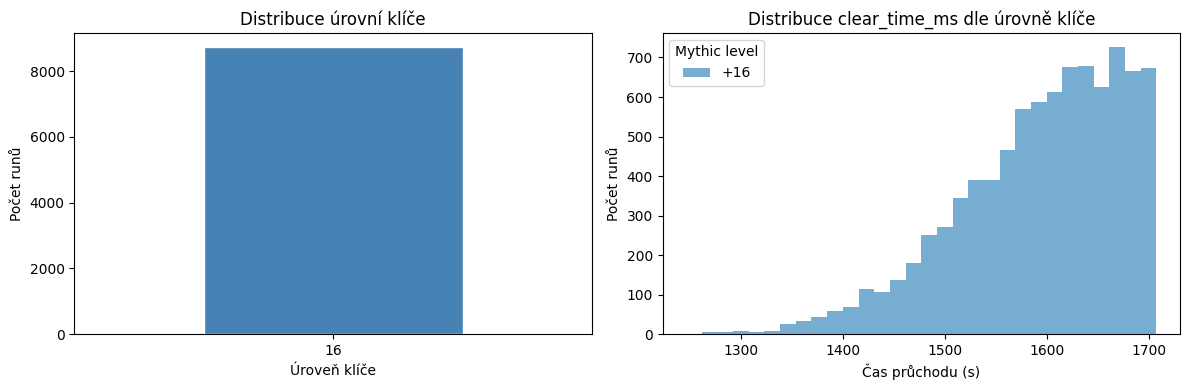

              count  mean_s  std_s
mythic_level                      
16             8730  1593.6   80.4


In [5]:
# Distribuce mythic_level a clear_time_ms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["mythic_level"].value_counts().sort_index().plot(kind="bar", ax=axes[0],
    color="steelblue", edgecolor="white")
axes[0].set_xlabel("Úroveň klíče")
axes[0].set_ylabel("Počet runů")
axes[0].set_title("Distribuce úrovní klíče")
axes[0].tick_params(axis="x", rotation=0)

for level, grp in df.groupby("mythic_level"):
    axes[1].hist(grp[TARGET] / 1000, bins=30, alpha=0.6, label=f"+{level}")
axes[1].set_xlabel("Čas průchodu (s)")
axes[1].set_ylabel("Počet runů")
axes[1].set_title("Distribuce clear_time_ms dle úrovně klíče")
axes[1].legend(title="Mythic level")

plt.tight_layout()
plt.show()

print(df.groupby("mythic_level")[TARGET].agg(
    count="count",
    mean_s=lambda x: (x.mean() / 1000).round(1),
    std_s=lambda x: (x.std() / 1000).round(1)
))

## 3. Leakage audit

Každý sloupec je zařazen do jedné z kategorií níže.

| Kategorie | Sloupce | Důvod |
|---|---|---|
| **Identifikátor** (drop) | `keystone_run_id`, `keystone_team_id` | Unikátní ID, nenesou prediktivní informaci |
| **Split only** (drop z features) | `completed_at` | Slouží pouze pro chronologický split |
| **Konstantní** (drop) | `season`, `dungeon_name`, `dungeon_short_name`, `dungeon_slug`, `dungeon_patch`, `mythic_level`, `keystone_time_ms` | Stejná hodnota v každém řádku po filtru na +16 |
| **Jméno hráče** (drop) | `tank_name`, `healer_name`, `dps_1_name`, `dps_2_name`, `dps_3_name` | Příliš vysoká kardinalita, nereprezentuje kompozici |
| **ID redundantní** (drop) | `*_race_id`, `*_class_id`, `*_spec_id` | Duplicitní informace k textovým názvům |
| **Pre-run feature** (ponechat) | `faction`, `modifier_*`, `*_class`, `*_spec`, `*_race`, `*_ilvl` | Dostupné před začátkem runu |
| **Cílová proměnná** | `clear_time_ms` | Post-run, slouží pouze jako target, nikdy jako feature |

## 4. Návrh splitu

**Typ splitu:** Chronologický podle `completed_at`, poměr **70 % train / 15 % validation / 15 % test**.

**Zdůvodnění:**
Týdenní affixy (`modifier_*`) se mění každý týden. Náhodný split by propustil informaci o konkrétních kombinacích afixů z trénovacích dat do validačních, což by vedlo k nerealisticky optimistickému odhadu výkonu. V reálném nasazení trénujeme model na historických runech a predikujeme na nových, chronologický split tento scénář přesně simuluje. Stejný tým (`keystone_team_id`) se může vyskytnout ve více runech, chronologický split zajistí, že budoucí runy stejného týmu nespadnou do trénovací sady.

## 5. Vytvoření a uložení train / validation / test sad

In [6]:
df["completed_at"] = pd.to_datetime(df["completed_at"], utc=True)
df = df.sort_values("completed_at").reset_index(drop=True)

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end].copy()
val   = df.iloc[train_end:val_end].copy()
test  = df.iloc[val_end:].copy()

for name, split in [("Train", train), ("Validation", val), ("Test", test)]:
    print(f"{name:<12} {len(split):>5} runů   "
          f"{split['completed_at'].min().date()} → {split['completed_at'].max().date()}")

Path("data").mkdir(exist_ok=True)
train.to_csv("data/train.csv",      index=False)
val.to_csv(  "data/validation.csv", index=False)
test.to_csv( "data/test.csv",       index=False)
print("\nSady uloženy do data/")

Train         6111 runů   2026-03-27 → 2026-04-23
Validation    1309 runů   2026-04-23 → 2026-04-25
Test          1310 runů   2026-04-25 → 2026-04-28

Sady uloženy do data/


## 6. Preprocessing pipeline

Všechny transformace, které se učí z dat (StandardScaler, OneHotEncoder), jsou **fitovány výhradně na trénovací sadě** a následně aplikovány na validační a testovací sadu.

### Přehled kroků
1. Drop nepotřebných sloupců (identifikátory, konstanty, jména, redundantní ID)
2. Odvozená proměnná `avg_group_ilvl` (průměr ilvl všech 5 hráčů)
3. Numerické features: imputace mediánem, poté StandardScaler
4. Kategorické features: imputace konstantou `"unknown"`, poté OneHotEncoder

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

COLS_DROP = [
    "keystone_run_id", "keystone_team_id", "completed_at", "season",
    "mythic_level", "keystone_time_ms",
    "dungeon_name", "dungeon_short_name", "dungeon_slug", "dungeon_patch",
    "tank_name", "healer_name", "dps_1_name", "dps_2_name", "dps_3_name",
    "tank_race_id", "tank_class_id", "tank_spec_id",
    "healer_race_id", "healer_class_id", "healer_spec_id",
    "dps_1_race_id", "dps_1_class_id", "dps_1_spec_id",
    "dps_2_race_id", "dps_2_class_id", "dps_2_spec_id",
    "dps_3_race_id", "dps_3_class_id", "dps_3_spec_id",
]

ILVL_COLS = ["tank_ilvl", "healer_ilvl", "dps_1_ilvl", "dps_2_ilvl", "dps_3_ilvl"]

NUMERICAL = ["avg_group_ilvl"] + ILVL_COLS

CATEGORICAL = [
    "faction",
    "modifier_1", "modifier_2", "modifier_3",
    "tank_race", "tank_class", "tank_spec",
    "healer_race", "healer_class", "healer_spec",
    "dps_1_race", "dps_1_class", "dps_1_spec",
    "dps_2_race", "dps_2_class", "dps_2_spec",
    "dps_3_race", "dps_3_class", "dps_3_spec",
]

print(f"Numerické features:    {len(NUMERICAL)}")
print(f"Kategorické features:  {len(CATEGORICAL)}")

Numerické features:    6
Kategorické features:  19


In [8]:
def prepare(df: pd.DataFrame) -> tuple:
    """Odstraní nepotřebné sloupce, odvodí avg_group_ilvl, oddělí target."""
    df = df.drop(columns=[c for c in COLS_DROP if c in df.columns])
    for col in ILVL_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["avg_group_ilvl"] = df[ILVL_COLS].mean(axis=1)
    y = df.pop(TARGET)
    return df, y

X_train, y_train = prepare(train.copy())
X_val,   y_val   = prepare(val.copy())
X_test,  y_test  = prepare(test.copy())

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (6111, 25)
X_val:   (1309, 25)
X_test:  (1310, 25)


In [9]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), NUMERICAL),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), CATEGORICAL),
], remainder="drop")

# Fit pouze na train
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_["cat"]["ohe"] \
    .get_feature_names_out(CATEGORICAL).tolist()
all_feature_names = NUMERICAL + cat_names

print(f"Výsledný počet features po OHE: {len(all_feature_names)}")
print(f"X_train_proc shape: {X_train_proc.shape}")

Výsledný počet features po OHE: 283
X_train_proc shape: (6111, 283)


In [10]:
# Ukázka prvních numerických a kategorických features po transformaci
sample = pd.DataFrame(X_train_proc[:3], columns=all_feature_names)
print("Numerické (první 3 řádky):")
print(sample[NUMERICAL].to_string())
print("\nUkázka OHE sloupců (první 3 řádky, prvních 10 kategorií):")
print(sample[cat_names[:10]].to_string())

Numerické (první 3 řádky):
   avg_group_ilvl  tank_ilvl  healer_ilvl  dps_1_ilvl  dps_2_ilvl  dps_3_ilvl
0       -2.132772  -0.963182    -0.986513   -1.493601   -0.953687   -1.253096
1       -1.437976  -0.802755    -0.434509   -1.046438   -0.615450   -1.064379
2       -1.386649  -0.626285    -0.361239   -1.202479   -0.371919   -1.451662

Ukázka OHE sloupců (první 3 řádky, prvních 10 kategorií):
   faction_alliance  faction_horde  faction_mixed  modifier_1_Fortified  modifier_1_Tyrannical  modifier_2_Fortified  modifier_2_Tyrannical  modifier_3_Xal'atath's Guile  tank_race_Blood Elf  tank_race_Dark Iron Dwarf
0               0.0            0.0            1.0                   1.0                    0.0                   0.0                    1.0                           1.0                  0.0                        0.0
1               0.0            0.0            1.0                   1.0                    0.0                   0.0                    1.0                           

## 7. Shrnutí

**Co bylo metodicky důležité:**
Dataset je filtrován na klíč +16, čímž odstraňujeme dominantní vliv obtížnosti na dobu průchodu. Chronologický split je nutností, náhodný split by způsobil leakage přes týdenní affixy. StandardScaler a OneHotEncoder jsou fitovány výhradně na train sadě, aplikace na val/test probíhá pouze přes `transform`.

**Co bylo obtížné:**
Dataset pochází z rankings endpointu, pokrývá tedy pouze top-ranked část EU populace. Výběrový bias je záměrný a odpovídá výzkumné otázce, ale výsledky nelze zobecňovat. Pořadí DPS hráčů (`dps_1`, `dps_2`, `dps_3`) je arbitrární, model může přikládat váhu pořadí, které nemá sémantický význam. V navazujícím modelování by dávalo smysl reprezentovat DPS jako množinu (bag of specs).

**Příští krok:**
Natrénovat model zahrnující composition features (class, spec) a porovnat s benchmarkovou laťkou **RMSE ≈ 89 s** na validační sadě.